# PVPlant 논문 구현하기

> Hybrid Deep Learning Models for Power Output Forecasting of Grid-Connected Solar PV Systems: A Monocrystalline and Polycrystalline PV Panel Analysis   
> - Owolabi et al. (2025)

[Notion | https://www.notion.so/ryudoyeon/Owaolabi-et-al-2025-28661f7ccc3f8096bb46c274dd8e5523?source=copy_link]

- IHS, CNN, LSTM 하이브리드 모델

## 1. Object Setting

- 선행 논문의 형식 대로 IHS + CNN + LSTM Hybrid Model 구축하기
    - IHS: CNN, LSTM parameter 최적화 
    - CNN: 단기적 특성 특성 파악
    - LSTM 장기적 특성 파악

- 현재는 IHS 과정 없이 논문에 나와있는 파라미터 + 기본값으로 학습 진행

라이브러리 불러오기 

In [210]:
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import math
import matplotlib.cm as cm
import sklearn.metrics as skm
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from utils.setup import SeqDataset_single_model
from torch.utils.data import DataLoader
from models.PVPlant_CNN import PVPlantCNN
from models.PVPlant_LSTM import PVPlantLSTM

from utils.train import train_cnn_lstm
from utils.evaluate_metrics import evaluate_cnn_lstm
from utils.evaluate_metrics import metrics_cnn_lstm

from plots.plot_prediction import plot_Owaolabi_predictions_chained
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Data preparation 

1. Data collection 
    - Weather data and PV output -> Collection meter
    - 상대적으로 완전하고 정확한 측정이 존재하는 년도 선택
    - 두 가지 종류의 solar PV technologies 선택
        - **station02**: 285Wp monocrystalline silicon (mono-si) PV manufactured by Risen Energy
        - **station08**: 265Wp polycrystalline silicon (poly-si) solar cell manufactured by Yingli
2. Data pre-proccessing and splitting
    - Raw data -> Data cleaning -> Data analysis
    - Data cleaning, resampling, splitting, denoising, normaization 
    
    - absolute correlation coefficient >= 0.35인 입력 변수만 모델 학습에 채택
        - nwp_globalirrad, nwp_directirrad, nwp_temperature,nwp_humidity, lmd_totalirrad, lmd_diffuseirrad, lmd_temperature
    - 정규화: MinMax Scaling (0-1) 
    - splitting
        - training set: 70%
        - testing set: 30%
            - validation set: 15%
            - fianl test: 15%
    - 표준화: z-score standardization 


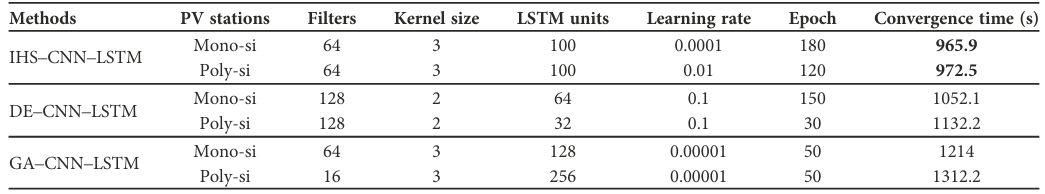

### 2.1 Mono-si, Poly-si 데이터 추출

metadata
- station별 특징을 통해 station02, 08만 채택
- mono: station02
- poly: station08

In [211]:
metadata = pd.read_csv("PVODdatasets_v1.0/metadata.csv")

# 조건 만족하는 행만 추출 (추후)
# mono = metadata[(metadata["Panel_Size"] == 1.6368) & (metadata["Array_Tilt"] == "South 29°")]
# poly = metadata[(metadata["Panel_Size"] == 1.6335) & (metadata["Array_Tilt"] == "South 33°")]

지도 시각화
- 두 station 모두 동일한 Hebei 지역에 위치

In [212]:
# station 지도 시각화

# Station02, Station03만 필터링
stations = metadata[metadata["Station_ID"].isin(["station02", "station08"])]

# 지도 초기화 (중심: 필터링된 좌표 평균)
m = folium.Map(location=[stations["Latitude"].mean(), stations["Longitude"].mean()], zoom_start=5)

# 마커 추가
for _, row in stations.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=f"Station: {row['Station_ID']}"
    ).add_to(m)
m.save("plots/Owaolabi/station_map.html")
m

station별 데이터

1. 열 설명
    - date_time: timstamp   
**NWP (Numerical Weather Prediction, 수치예보 모델 출력 값)**   
    - nwp_globalirrad: Global Irradiance (태양이 지표면에 도달하는 총 일사량 (W/m2))
    - nwp_directirrad: Direct Irradiance (태양에서 직접 도달하는 일사 성분 (W/m2))
    - nwp_temperature: 기온, NWP에서 예측된 값
    - nwp_humidity: 상대습도, NWP에서 예측된 값
    - nwp_windspeed: 풍속, NWP 예보 값
    - nwp_winddirection: 풍향, NWP 예보 값
    - nwp_pressure: 기압, NWP 예보 값   
**LMD (Local Meteorological Data, 현장 기상 관측 데이터)**   
    - lmd_totalirrad: 총 일사량(Global Irradiance), 현장 측정 값   
    - lmd_diffuseirrad: 산란일사량(Diffuse Irradiance), 구름/대기 산란을 통해 도달하는 성분
    - lmd_temperature: 기온, 현장 기상 센서 측정 값
    - lmd_pressure: 기압, 현장 기상 센서 측정 값
    - lmd_winddirection: 풍향, 현장 측정 값
    - lmd_windspeed: 풍속, 현장 측정 값   
**발전소 성능**   
    - power: 실제 발전소의 전력 출력   

In [213]:
mono_station = pd.read_csv("PVODdatasets_v1.0/station02.csv")
poly_station = pd.read_csv("PVODdatasets_v1.0/station08.csv")

mono_station["Station_ID"] = "station02"
poly_station["Station_ID"] = "station08"

# 공통 데이터프레임 생성
stations = pd.concat([mono_station, poly_station], ignore_index=True)

# Station_ID를 맨 처음으로 이동
stations = stations[["Station_ID"] + [col for col in stations.columns if col != "Station_ID"]]

# Station_ID 열 제거
mono_station.drop(columns=["Station_ID"], inplace=True)
poly_station.drop(columns=["Station_ID"], inplace=True)

### 2.2 Data Inspection

각 발전소별 power 시계열 시각화
- station별 누락값이 존재함을 파악, 우선 pass (Nan값이 아닌 timestamp 자체 누락)
- station별 timestamp 범위 다름
- 0 ~ 17.5 사이에 power 데이터 분포

In [214]:
# date_time 컬럼이 문자열이면 datetime 변환
stations['date_time'] = pd.to_datetime(stations['date_time'])

# 발전소 ID 목록
station_ids = stations['Station_ID'].unique()

# # 시각화
# plt.figure(figsize=(12, 8))

# for i, station_id in enumerate(station_ids, 1):
#     subset = stations[stations['Station_ID'] == station_id]
    
#     plt.subplot(len(station_ids), 1, i)
#     plt.plot(subset['date_time'], subset['power'])
#     plt.title(f'{station_id} Power Over Time')
#     plt.xlabel('Time')
#     plt.ylabel('Power')

# plt.tight_layout()
# plt.show()

변수별 특성 및 power와의 상관 관계 파악

In [215]:
# 기상 변수 - power 산점도

# 기상 변수 목록 (Station_ID, date_time, power 제외)
weather_cols = [col for col in stations.columns if col not in ['Station_ID', 'date_time', 'power']]
colors = cm.tab10(np.linspace(0, 1, len(weather_cols))) 

# # 시각화
# for station_id in station_ids:
#     subset = stations[stations['Station_ID'] == station_id]
    
#     ncols = 4
#     nrows = math.ceil(len(weather_cols) / ncols)
    
#     plt.figure(figsize=(6*ncols, 4*nrows))
#     plt.suptitle(f"{station_id} - Weather Variables vs Power", fontsize=16, y=1.02)
    
#     for j, col in enumerate(weather_cols):
#         ax = plt.subplot(nrows, ncols, j+1)
#         ax.scatter(subset[col], subset['power'], alpha=0.5, s=10, color=colors[j])
#         ax.set_title(col)
#         ax.set_xlabel(col)
#         ax.set_ylabel("Power")
    
#     plt.tight_layout()
#     plt.show()

In [216]:
# 변수별 시간대별 시각화

# for station_id in station_ids:
#     subset = stations[stations['Station_ID'] == station_id]
    
#     ncols = 3
#     nrows = math.ceil(len(weather_cols) / ncols)
    
#     plt.figure(figsize=(6*ncols, 3*nrows))
#     plt.suptitle(f"{station_id} Weather Variables Over Time", fontsize=16, y=1.02)
    
#     for i, col in enumerate(weather_cols, 1):
#         ax = plt.subplot(nrows, ncols, i)
#         ax.plot(subset['date_time'], subset[col], color=colors[i-1], alpha=0.7)
#         ax.set_title(col)
#         ax.set_xlabel("Time")
#         ax.set_ylabel("Value")
    
#     plt.tight_layout()
#     plt.show()

In [217]:
# # 기상 변수 - power 상관 관계 히트맵

# # numeric 컬럼만 선택
# numeric_cols = stations.select_dtypes(include=['float64','int64']).columns
# corr = stations[numeric_cols].corr()

# plt.figure(figsize=(10, 8))
# sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
# plt.title("Correlation Heatmap with PV Output")
# plt.show()


### 2.3 Data Preprocessing

이후의 과정은 학습 데이터의 구분을 위해 
- tgt_station으로 mono, polystation 선택하도록 설정함 (target_station)

In [218]:
# 두 데이터 바꿀 땐 tgt_station 설정만 바꾸기
tgt_station = poly_station.copy()
tgt_station_name = "poly"

In [219]:
# 상관관계가 0.35 이상인 기상 변수들만 남기고 drop
tgt_station = tgt_station.drop(columns=['nwp_windspeed', 'nwp_winddirection', 'nwp_pressure', 'nwp_pressure', 'lmd_winddirection', 'lmd_windspeed', 'lmd_pressure'])

앞서 언급한 누락값 보정 관련
- 우선 패스

In [220]:
# # 1) 안전: datetime으로 변환
# mono_station["date_time"] = pd.to_datetime(mono_station["date_time"])

# # 2) 2019-01-31 "하루 전체" 포함해서 자르기
# end = pd.to_datetime("2019-02-01")  # 다음날 00:00 미만
# mono_station = mono_station.loc[mono_station["date_time"] < end].copy()


In [221]:
# import pandas as pd

# # Station02만 선택
# station02 = stations[stations["Station_ID"] == "station02"].copy()
# station02["date_time"] = pd.to_datetime(station02["date_time"], errors="coerce")

# # 인덱스 설정
# station02 = station02.set_index("date_time").sort_index()

# # 15분 단위로 재샘플링 (NaN 유지)
# station02_resampled = station02.resample("15T").asfreq()
# # station02_resampled = station02_resampled.interpolate(method="linear")
# # date_time을 다시 컬럼으로 복구
# station02_resampled = station02_resampled.reset_index()

# # Station_ID 컬럼이 사라졌다면 다시 넣어줌
# station02_resampled["Station_ID"] = "station02"

# # 기존 stations에서 Station02 제거 후 새 데이터 붙이기
# stations = pd.concat(
#     [
#         stations[stations["Station_ID"] != "station02"],
#         station02_resampled
#     ],
#     ignore_index=True
# ).sort_values(["Station_ID", "date_time"]).reset_index(drop=True)

# print("Before Station02:", station02.shape)
# print("After Station02:", station02_resampled.shape)
# print("최종 stations 크기:", stations.shape)


In [222]:
# import pandas as pd

# # Station08만 선택
# station08 = stations[stations["Station_ID"] == "station08"].copy()
# station08["date_time"] = pd.to_datetime(station08["date_time"], errors="coerce")

# # 인덱스 설정
# station08 = station08.set_index("date_time").sort_index()

# # 15분 단위로 재샘플링 (NaN 유지)
# station08_resampled = station08.resample("15T").asfreq()
# # station08_resampled = station08_resampled.interpolate(method="linear")
# # date_time을 다시 컬럼으로 복구
# station08_resampled = station08_resampled.reset_index()

# # Station_ID 컬럼이 사라졌다면 다시 넣어줌
# station08_resampled["Station_ID"] = "station08"

# # 기존 stations에서 Station08 제거 후 새 데이터 붙이기
# stations = pd.concat(
#     [
#         stations[stations["Station_ID"] != "station08"],
#         station08_resampled
#     ],
#     ignore_index=True
# ).sort_values(["Station_ID", "date_time"]).reset_index(drop=True)

# print("Before Station08:", station08.shape)
# print("After Station08:", station08_resampled.shape)
# print("최종 stations 크기:", stations.shape)


In [223]:
# 각 발전소별 시계열 데이터 범위 확인
for station_id, group in stations.groupby("Station_ID"):
    min_date = pd.to_datetime(group['date_time']).min()
    max_date = pd.to_datetime(group['date_time']).max()
    print(f"Station {station_id}: {min_date} to {max_date}, Total records: {len(group)}")

Station station02: 2018-07-22 16:00:00 to 2019-06-10 15:45:00, Total records: 30432
Station station08: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33120


In [224]:
# station별 그룹화 후 NaN 개수 집계
# 없음
mono_station_nan_counts = mono_station.isna().sum()
poly_station_nan_counts = poly_station.isna().sum()

print("Station02 NaN counts:\n", mono_station_nan_counts)
print("\nStation08 NaN counts:\n", poly_station_nan_counts)

Station02 NaN counts:
 date_time            0
nwp_globalirrad      0
nwp_directirrad      0
nwp_temperature      0
nwp_humidity         0
nwp_windspeed        0
nwp_winddirection    0
nwp_pressure         0
lmd_totalirrad       0
lmd_diffuseirrad     0
lmd_temperature      0
lmd_pressure         0
lmd_winddirection    0
lmd_windspeed        0
power                0
dtype: int64

Station08 NaN counts:
 date_time            0
nwp_globalirrad      0
nwp_directirrad      0
nwp_temperature      0
nwp_humidity         0
nwp_windspeed        0
nwp_winddirection    0
nwp_pressure         0
lmd_totalirrad       0
lmd_diffuseirrad     0
lmd_temperature      0
lmd_pressure         0
lmd_winddirection    0
lmd_windspeed        0
power                0
dtype: int64


Train / Valid / Test 분할하기

In [225]:
def split_train_val_test(station_data=tgt_station, train_ratio=0.7, val_ratio=0.15):    
    train_data = pd.DataFrame()
    val_data = pd.DataFrame()
    test_data = pd.DataFrame()

    total_len = len(station_data)
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))

    train_data = pd.concat([train_data, station_data.iloc[:train_end]])
    val_data = pd.concat([val_data, station_data.iloc[train_end:val_end]])
    test_data = pd.concat([test_data, station_data.iloc[val_end:]])

    # 인덱스 재설정
    train_data = train_data.reset_index(drop=True)
    val_data = val_data.reset_index(drop=True)
    test_data = test_data.reset_index(drop=True)

    return train_data, val_data, test_data

In [226]:
train, valid, test = split_train_val_test(tgt_station)

# 추후 시각화를 위해 원본 복사
train_origin = train.copy()
valid_origin = valid.copy()
test_origin = test.copy()

# feature / target 분리 target = y = power
train_y = pd.DataFrame(train["power"])
valid_y = pd.DataFrame(valid["power"])
test_y = pd.DataFrame(test["power"])

In [227]:
# 각 발전소별 분할된 시계열 데이터 범위 확인
def get_date_range(df):
    date_ranges = {}
    min_date = pd.to_datetime(df['date_time']).min()
    max_date = pd.to_datetime(df['date_time']).max()
    date_ranges = {min_date, max_date}
    return date_ranges

print("Train Date:\n", get_date_range(train))
print("Validation Date:\n", get_date_range(valid))
print("Test Date:\n", get_date_range(test))

Train Date:
 {Timestamp('2018-06-30 16:00:00'), Timestamp('2019-03-02 03:45:00')}
Validation Date:
 {Timestamp('2019-03-02 04:00:00'), Timestamp('2019-04-22 21:45:00')}
Test Date:
 {Timestamp('2019-04-22 22:00:00'), Timestamp('2019-06-13 15:45:00')}


In [228]:
# date_time 컬럼 제거
train = train.drop(columns=["date_time"])
valid = valid.drop(columns=["date_time"])
test = test.drop(columns=["date_time"])

Data cleaning

In [229]:
# 이상치 NaN값 처리 

# NaN값 처리 


# 처리 과정이 논문에 나오지 않아 생략했을 때 결과를 보고 판단하기로 함
# NaN값은 현재 없는 상태

정규화, 표준화
- MinMax Scaling & z-score standardization

In [230]:
MinMaxscaler = MinMaxScaler() # 0~1 사이로 정규화
Standardscaler = StandardScaler() # 평균 0, 표준편차 1로 표준화

# train_data
# fit_transform 모두 
def train_scaler_fit_transform(df, scaler):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df, scaler

# valid / test_data
# transform only
def valid_test_scaler_transform(df, scaler):
    df = df.copy()
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    return df

# Min-Max scaling
train_minmax, minmax_scaler = train_scaler_fit_transform(train, MinMaxscaler)
valid_minmax = valid_test_scaler_transform(valid, minmax_scaler)
test_minmax = valid_test_scaler_transform(test,  minmax_scaler)

# z-score standardization
train_scaled, standard_scaler = train_scaler_fit_transform(train_minmax, Standardscaler)
valid_scaled = valid_test_scaler_transform(valid_minmax, standard_scaler)
test_scaled  = valid_test_scaler_transform(test_minmax, standard_scaler)

In [231]:
# target power에 대해서도 동일하게 진행
# feature / target 분리해서 진행해야 함
# y_xx_scaled: 추후 역변환 시 사용

# Min-Max scaling
train_minmax_y, y_minmax_scaled = train_scaler_fit_transform(train_y, MinMaxscaler)
valid_minmax_y = valid_test_scaler_transform(valid_y, MinMaxscaler)
test_minmax_y = valid_test_scaler_transform(test_y, MinMaxscaler)

# z-score standardization
train_scaled_y, y_standard_scaled = train_scaler_fit_transform(train_minmax_y, Standardscaler)
valid_scaled_y = valid_test_scaler_transform(valid_minmax_y, Standardscaler)
test_scaled_y  = valid_test_scaler_transform(test_minmax_y, Standardscaler)

슬라이딩 윈도우 생성

In [232]:
def sliding_window(df, input_window, output_window,
                    target_col="power", keep_target_in_x=True):
    """
    Function: sliding_window
        - input_window 길이 만큼의 슬라이딩 윈도우를 사용하여
          output_window 길이 만큼의 타겟 생성
    Parameters:
        - df: pandas DataFrame, 단일 발전소의 시계열 데이터 (tgt_station(mono_station / poly_station))
        - input_window: input_window 길이 
        - output_window: output_window 길이
        - target_col: 타겟 컬럼명 (default: "power")
        - keep_target_in_x: 입력 피처에 타겟 컬럼 포함 여부 (default: True)
    Returns:
        - x_arr: torch.Tensor, shape (N, input_window, F)
        - y_arr: torch.Tensor, shape (N, output_window) or (N,)
          (output_window=1일 때는 (N,)로 차원 축소)
        - N: 생성된 샘플 수
    Note:
        - N = T - input_window - output_window + 1 (T: 전체 타임스탬프 수)
        - F: feature 수
        - L: input_window
    """
    xs, ys = [], [] # 입력과 타겟 리스트

    # 인덱스 초기화
    sub = df.reset_index(drop=True)

    # 숫자형 feature 선택
    numeric_cols = sub.select_dtypes(include=[np.number]).columns.tolist()
    feat_cols = numeric_cols.copy()
    if not keep_target_in_x:
        feat_cols = [c for c in feat_cols if c != target_col]
    
    X = sub[feat_cols].to_numpy()
    y_all = pd.to_numeric(sub[target_col], errors="coerce").to_numpy()

    T = len(sub)
    N = T - input_window - output_window + 1
    if N <= 0:
        return None, None

    for i in range(N):
        xs.append(X[i:i+input_window]) #
        ys.append(y_all[i+input_window:i+input_window+output_window])

    x_arr = np.stack(xs).astype(np.float32) # (N, L, F)
    y_arr = np.stack(ys).astype(np.float32) # (N, output_window)

    # output_window = 1 일 때 차원 축소 (N, 1) -> (N,)
    if y_arr.shape[1] == 1:
        y_arr = y_arr[:, 0]

    return torch.from_numpy(x_arr), torch.from_numpy(y_arr) # torch.Tensor로 변환

In [ ]:
input_window = 10 #  15 * 10 분 입력
output_window = 1 # 15분 예측

# sliding_window, torch.Tensor 변환
torch_train_x, torch_train_y = sliding_window(
    train_scaled, input_window, output_window,
    target_col="power", keep_target_in_x=True
)

In [234]:
torch_valid_x, torch_valid_y = sliding_window(
    valid_scaled, input_window, output_window,
    target_col="power", keep_target_in_x=True
)

In [235]:
torch_test_x, torch_test_y = sliding_window(
    test_scaled, input_window, output_window,
    target_col="power", keep_target_in_x=True
)

## 3. Model training

1. IHS Algorithm
    - Harmony Initialization 
    - Fitness Evaluation and Harmony Selection 
    - Termination 
2. DE (Differencial Evolution) and GA
    - Initialization 
    - Selection 
    - Mutation 
    - Crossover and Evaluation 
    - Termination 
3. CNN
4. LSTM 
5. Ensemble Architecture of CNN and LSTM    

### IHS Algorithm

우선 생략
- 논문에 명시된 최적 파라미터와 기본값으로만 모델 구성
- 결과가 크게 다르지 않음을 확인

### CNN + LSTM

Mono-si   
- Filters = 64
- Kernal size = 3 
- Lstm units = 100
- Learning rate = 0.001
- Epoch = 180
- Convergence time(s) = 965.9

Poly-si    
- Filters = 64
- Kernal size = 3 
- Lstm units = 100
- Learning rate = 0.01
- Epoch = 120
- Convergence time(s) = 972.5

CNN

In [236]:
# CNN 파라미터 설정

in_channels = 8 # 입력 피처 수 (station의 기상 변수 + power)
out_channels = 64 # CNN에서 추출할 feature map 수 (입력 feature를 통해 out_channels 수 만큼 새로운 특징 추출)
kernel_size = 3 # 커널 크기
stride = 1 # kernel 이동 간격
dilation = 1 # kernel 사이의 간격
padding = 1 # 입력 양 쪽에 채워 넣는 padding 크기
groups = 1 # 1: default
bias = True # bias 사용
padding_mode = 'zeros' # padding 채우는 값
cnn_dropout = 0.1 # dropout 비율
pool_kernel_size = 2 # MaxPooling kernel size
pool_stride = 2 # MaxPooling stride
lstm_in_features = 32 # LSTM 입력 피처 수 # out_channels에서 fully connected layer로 축소
use_bn = True # Batch Normalization 사용 여부

In [237]:
# CNN 모델 생성
cnn = PVPlantCNN(
    in_channels=in_channels,
    out_channels=out_channels,
    kernel_size=kernel_size,
    stride=stride,
    dilation=dilation,
    padding=padding,
    groups=groups,
    bias=bias,
    padding_mode=padding_mode,
    dropout=cnn_dropout,
    pool_kernel_size=pool_kernel_size,
    pool_stride=pool_stride,
    lstm_in_features=lstm_in_features,
    use_bn=use_bn
).to(device)
cnn

PVPlantCNN(
  (cnn): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): LazyLinear(in_features=0, out_features=32, bias=True)
)

LSTM

In [238]:
# LSTM 파라미터 설정
input_size = lstm_in_features # LSTM 입력 피처 수 # CNN 모델의 출력 피처 수와 동일
hidden_size = 100 # LSTM hidden state 크기
output_size = output_window # 예측하고자 하는 타겟 크기. 논문: 1
num_lstm_layers = 1 # LSTM 레이어 수
num_stations = None # 발전소 수 (None: 단일 발전소)
station_emb_dim = 0 # 발전소 임베딩 차원 (0: 단일 발전소)
meta_dim = 0 # 메타 데이터 차원 (0: 단일 발전소 - 메타 데이터 없음)
lstm_dropout = 0.1 # dropout 비율

In [239]:
# LSTM 모델 생성
lstm = PVPlantLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size,
    num_layers=num_lstm_layers,
    num_stations=num_stations,
    station_emb_dim=station_emb_dim,
    meta_dim=meta_dim,
    dropout=lstm_dropout
).to(device)
lstm

PVPlantLSTM(
  (lstm): LSTM(32, 100, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=100, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=50, out_features=24, bias=True)
  )
)

### Training

In [240]:
# (x, y)만 생성
train_ds = SeqDataset_single_model(torch_train_x, torch_train_y)
valid_ds = SeqDataset_single_model(torch_valid_x, torch_valid_y)
test_ds  = SeqDataset_single_model(torch_test_x,  torch_test_y)

batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())

In [ ]:
criterion = nn.HuberLoss(delta=1.0, reduction="mean") # Huber Loss
# CNN+LSTM 파라미터를 하나의 optimizer에 넣기
# lr: station별로 수정 필요
optimizer = torch.optim.Adam(list(cnn.parameters()) + list(lstm.parameters()), lr=1e-4)

num_epochs = 180
best_loss = float('inf')
best_cnn_path = f'results/Owaolabi/best_cnn_{tgt_station_name}.pth'
best_lstm_path = f'results/Owaolabi/best_lstm_{tgt_station_name}.pth'

for epoch in range(1, num_epochs + 1):
    # 1. 학습
    train_loss = train_cnn_lstm(train_loader, cnn, lstm, criterion, optimizer, device)

    # 2. 검증: 평균 손실
    overall_loss = evaluate_cnn_lstm(valid_loader, cnn, lstm, criterion, device)

    # 3. best model 저장 
    if overall_loss < best_loss:
        best_loss = overall_loss
        torch.save(cnn.state_dict(), best_cnn_path)
        torch.save(lstm.state_dict(), best_lstm_path)
        print(f"[{tgt_station_name}] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

    # 4. 출력: train / valid 평균 손실
    print(f"[{tgt_station_name}] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")

[poly] (001) Saved best | valid loss: 0.563067
[poly] (001) train 0.388006 | valid 0.563067
[poly] (002) Saved best | valid loss: 0.517097
[poly] (002) train 0.358361 | valid 0.517097
[poly] (003) Saved best | valid loss: 0.458935
[poly] (003) train 0.312193 | valid 0.458935
[poly] (004) Saved best | valid loss: 0.391686
[poly] (004) train 0.266632 | valid 0.391686
[poly] (005) Saved best | valid loss: 0.341400
[poly] (005) train 0.227202 | valid 0.341400
[poly] (006) Saved best | valid loss: 0.301276
[poly] (006) train 0.200628 | valid 0.301276
[poly] (007) Saved best | valid loss: 0.281337
[poly] (007) train 0.182764 | valid 0.281337
[poly] (008) Saved best | valid loss: 0.263002
[poly] (008) train 0.169362 | valid 0.263002
[poly] (009) Saved best | valid loss: 0.249643
[poly] (009) train 0.159974 | valid 0.249643
[poly] (010) train 0.153178 | valid 0.250389
[poly] (011) Saved best | valid loss: 0.241015
[poly] (011) train 0.148871 | valid 0.241015
[poly] (012) train 0.144389 | valid

## 4. Model performance evaluation

- Mono
    - 논문   
        - MAE: 1.804
        - RMSE: 4.035
        - R2: 0.982
        - FSI: 0.258
    - 새 모델
        - MAE: 0.4337
        - RMSE: 0.9447
        - MAPE: 153977.0000
        - R2: 0.9564
        - FSI:base model (cnn_lstm)이 없어서 pass
- Poly
    - 논문
        - MAE: 1.150
        - RMSE: 2.643
        - R2: 0.993
        - FSI:0.463
    - 새 모델
        - MAE: 0.5914
        - RMSE: 1.1640
        - MAPE: 271416.4375
        - R2: 0.9474
        - FSI: base model (cnn_lstm)이 없어서 pass

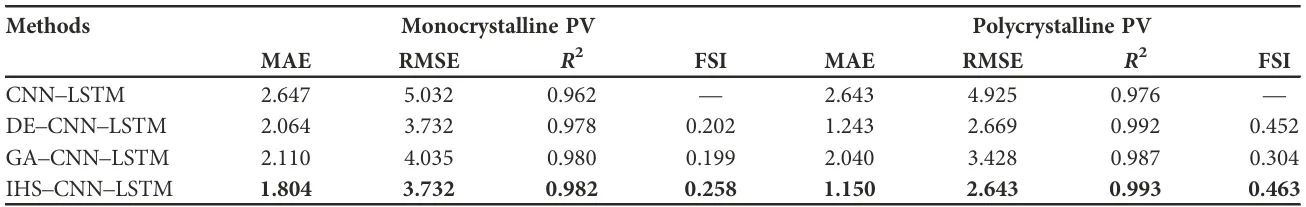

In [242]:
val_mae, val_rmse, val_mape, val_r2 = metrics_cnn_lstm(
    best_cnn_path, best_lstm_path, cnn, lstm,
    valid_loader, y_standard_scaled, y_minmax_scaled, device
)
print(f"[{tgt_station_name} CNN_LSTM] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")

[poly CNN_LSTM] Valid MAE: 1.4846, RMSE: 2.6170, MAPE: 948399.2500, R2: 0.7485


In [243]:
test_mae, test_rmse, test_mape, test_r2 = metrics_cnn_lstm(
    best_cnn_path, best_lstm_path, cnn, lstm,
    test_loader, y_standard_scaled, y_minmax_scaled, device
)
print(f"[{tgt_station_name} CNN_LSTM] Test MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, MAPE: {test_mape:.4f}, R2: {test_r2:.4f}")

[poly CNN_LSTM] Test MAE: 1.5066, RMSE: 2.5882, MAPE: 743850.5000, R2: 0.7377


## 5. Deployment

- 시각화 

Valid data

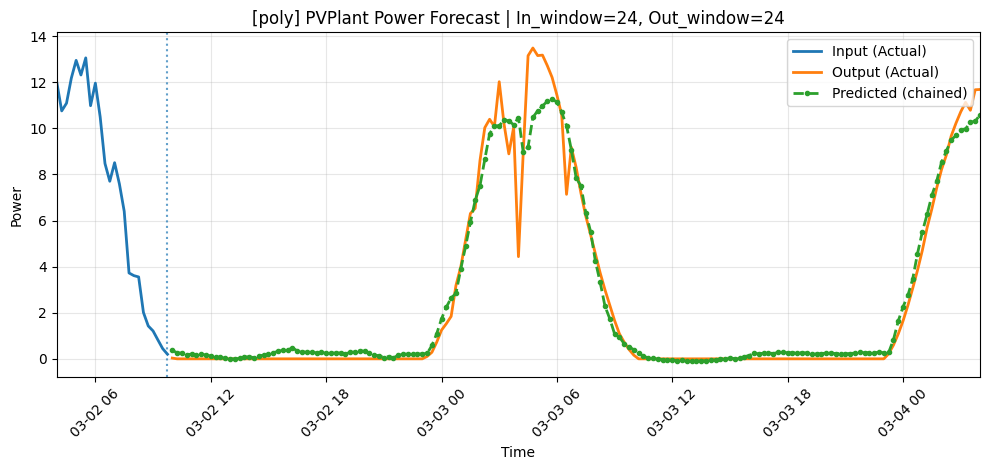

In [ ]:
plot_Owaolabi_predictions_chained(
    cnn, lstm, valid_loader, valid_origin, device,
    input_len=input_window, output_len=output_window, start_idx=0,
    std_scaler=y_standard_scaled, mm_scaler=y_minmax_scaled,logged=False, 
    view_days=2, tgt_station_name=tgt_station_name,
    save_path=f"plots/Owaolabi/{tgt_station_name}_2days_valid.png"
)

Test data

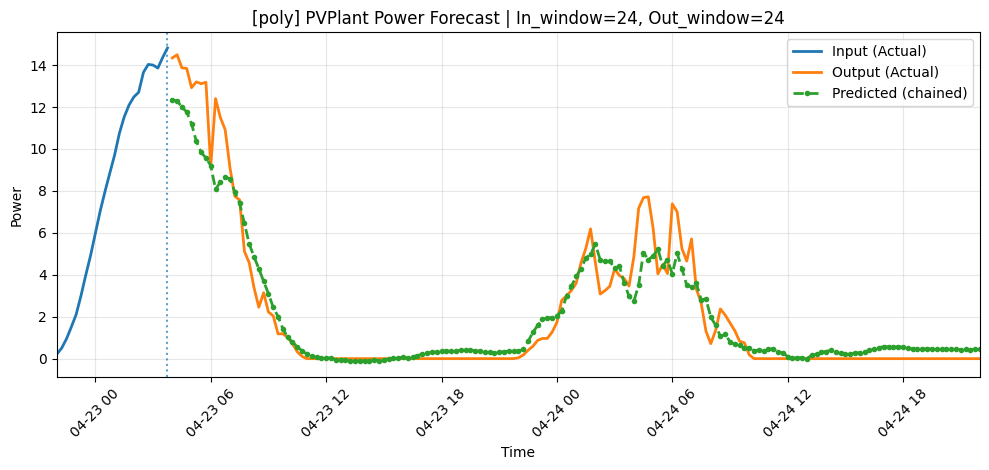

In [ ]:
plot_Owaolabi_predictions_chained(
    cnn, lstm, test_loader, test_origin, device,
    input_len=input_window, output_len=output_window, start_idx=0,
    std_scaler=y_standard_scaled, mm_scaler=y_minmax_scaled,logged=False,
    view_days=2, tgt_station_name=tgt_station_name,
    save_path=f"plots/Owaolabi/{tgt_station_name}_2days_test.png"
)

## 7. 하이퍼 파라미터 및 모델 조정

In [192]:
from utils.evaluate_metrics import evaluate
from utils.evaluate_metrics import metrics
from utils.train import train
from models.PVPlant_Transformer import PVPlantTransformer
from models.Transformer import TimeSeriesTransformer

##### 1. LSTM 단일 모델

In [193]:
# LSTM 모델 생성
lstm = PVPlantLSTM(
    input_size=in_channels, # LSTM에 처음 data input이므로 변수 개수와 동일하게 들어가야 함
    hidden_size=hidden_size,
    output_size=output_size,
    num_layers=num_lstm_layers,
    num_stations=num_stations,
    station_emb_dim=station_emb_dim,
    meta_dim=meta_dim,
    dropout=lstm_dropout
).to(device)
lstm

PVPlantLSTM(
  (lstm): LSTM(8, 100, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=100, out_features=50, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [194]:
# LSTM 단일 모델 
criterion = nn.HuberLoss(delta=1.0, reduction="mean") # Huber Loss
# CNN+LSTM 파라미터를 하나의 optimizer에 넣기
# lr: station별로 수정 필요
optimizer = torch.optim.Adam(list(lstm.parameters()), lr=1e-4)

num_epochs = 180
best_loss = float('inf')
best_lstm_path = f'results/Owaolabi/best_single_lstm_{tgt_station_name}.pth'

for epoch in range(1, num_epochs + 1):
    # 1. 학습
    train_loss = train(train_loader, lstm, criterion, optimizer, device)
    # 2. 검증: 평균 손실
    overall_loss, station_avg = evaluate(valid_loader, lstm, criterion, device)
    #    station_avg = {} # 단일 발전소이므로 station별 손실은 필요 없음
    # 3. best model 저장 
    if overall_loss < best_loss:
        best_loss = overall_loss
        torch.save(lstm.state_dict(), best_lstm_path)
        print(f"[{tgt_station_name}] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

    # 4. 출력: train / valid 평균 손실
    print(f"[{tgt_station_name}] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")

[poly] (001) Saved best | valid loss: 0.497686
[poly] (001) train 0.380952 | valid 0.497686
[poly] (002) Saved best | valid loss: 0.357976
[poly] (002) train 0.297007 | valid 0.357976
[poly] (003) Saved best | valid loss: 0.202018
[poly] (003) train 0.165352 | valid 0.202018
[poly] (004) Saved best | valid loss: 0.141727
[poly] (004) train 0.105816 | valid 0.141727
[poly] (005) Saved best | valid loss: 0.093059
[poly] (005) train 0.079031 | valid 0.093059
[poly] (006) Saved best | valid loss: 0.052832
[poly] (006) train 0.054844 | valid 0.052832
[poly] (007) Saved best | valid loss: 0.036607
[poly] (007) train 0.038389 | valid 0.036607
[poly] (008) Saved best | valid loss: 0.032859
[poly] (008) train 0.033316 | valid 0.032859
[poly] (009) Saved best | valid loss: 0.031832
[poly] (009) train 0.031223 | valid 0.031832
[poly] (010) train 0.029896 | valid 0.031884
[poly] (011) Saved best | valid loss: 0.029656
[poly] (011) train 0.029065 | valid 0.029656
[poly] (012) Saved best | valid los

In [195]:
val_mae, val_rmse, val_mape, val_r2 = metrics(
    best_lstm_path, lstm,
    valid_loader, y_standard_scaled, y_minmax_scaled, logged=False, device=device
)
print(f"[{tgt_station_name} Single_LSTM] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")

[poly Single_LSTM] Valid MAE: 0.3419, RMSE: 0.8219, MAPE: 45314.8867, R2: 0.9751


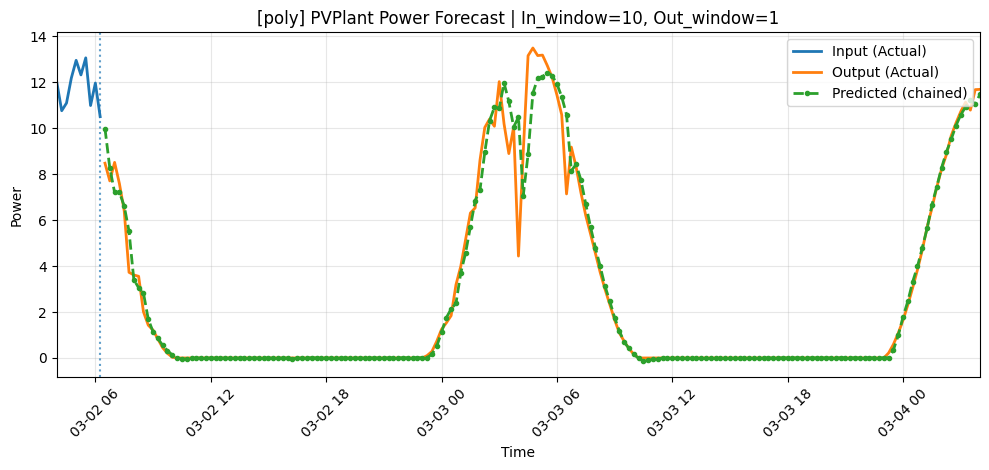

In [196]:
plot_Owaolabi_predictions_chained(
    None, lstm, valid_loader, valid_origin, device,
    input_len=input_window, output_len=output_window, start_idx=0,
    std_scaler=y_standard_scaled, mm_scaler=y_minmax_scaled,logged=False, 
    view_days=2, tgt_station_name=tgt_station_name,
    save_path=f"plots/Owaolabi/Single_LSTM_{tgt_station_name}_2days_valid.png"
)

##### 2. Transformer 단일 모델

In [197]:
# 공통 파라미터
input_size  = in_channels# torch_train_x.shape[-1] # 22
d_model = 128
nhead = 8
dim_feedforward = 512
num_ts_layers = 3

In [198]:
Transformer = TimeSeriesTransformer(
    input_dim=input_size,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_ts_layers,
    dim_feedforward=dim_feedforward,
    output_window=output_window,
    dropout=0.1,
    max_len = input_window,
).to(device)
Transformer

TimeSeriesTransformer(
  (embedding): TimeSeriesEmbedding(
    (input_proj): Linear(in_features=8, out_features=128, bias=True)
    (pos_encoder): PositionalEncoding()
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (enc_norm)

In [199]:
# # Transformer 파라미터

# Transformer = PVPlantTransformer(
#     input_size=input_size, # LSTM의 input_size와 동일
#     d_model=d_model, # hidden_size
#     output_size=output_size, # 예측 스텝 수
#     num_layers=num_ts_layers, # 인코더 레이어 수
#     num_stations=num_stations, # station 개수
#     station_emb_dim=station_emb_dim, # station 임베딩 차원
#     meta_dim=meta_dim, # 메타 피처 차원
#     dropout=0.1, # 드롭아웃 비율
#     nhead=nhead, # 멀티헤드 어텐션 헤드 수
#     dim_feedforward=dim_feedforward, # 피드포워드 네트워크 차원
#     max_len=input_window, # 최대 시퀀스 길이
#     pool="last" 
# ).to(device)
# Transformer

In [200]:
criterion = nn.HuberLoss(delta=1.0, reduction="mean") # Huber Loss
# CNN+LSTM 파라미터를 하나의 optimizer에 넣기
# lr: station별로 수정 필요
optimizer = torch.optim.Adam(list(Transformer.parameters()), lr=1e-4)

num_epochs = 180
best_loss = float('inf')
best_path = f'results/Owaolabi/best_single_transformer_{tgt_station_name}.pth'

for epoch in range(1, num_epochs + 1):
    # 1. 학습
    train_loss = train(train_loader, Transformer, criterion, optimizer, device)
    # 2. 검증: 평균 손실
    overall_loss, station_avg = evaluate(valid_loader, Transformer, criterion, device)
    #    station_avg = {} # 단일 발전소이므로 station별 손실은 필요 없음
    # 3. best model 저장 
    if overall_loss < best_loss:
        best_loss = overall_loss
        torch.save(Transformer.state_dict(), best_path)
        print(f"[{tgt_station_name}] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

    # 4. 출력: train / valid 평균 손실
    print(f"[{tgt_station_name}] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")

[poly] (001) Saved best | valid loss: 0.145548
[poly] (001) train 0.242662 | valid 0.145548
[poly] (002) Saved best | valid loss: 0.084036
[poly] (002) train 0.096986 | valid 0.084036
[poly] (003) Saved best | valid loss: 0.060117
[poly] (003) train 0.071581 | valid 0.060117
[poly] (004) Saved best | valid loss: 0.047493
[poly] (004) train 0.059834 | valid 0.047493
[poly] (005) Saved best | valid loss: 0.042361
[poly] (005) train 0.055010 | valid 0.042361
[poly] (006) Saved best | valid loss: 0.039736
[poly] (006) train 0.049190 | valid 0.039736
[poly] (007) Saved best | valid loss: 0.036614
[poly] (007) train 0.047746 | valid 0.036614
[poly] (008) Saved best | valid loss: 0.036186
[poly] (008) train 0.046639 | valid 0.036186
[poly] (009) train 0.045324 | valid 0.039540
[poly] (010) Saved best | valid loss: 0.033969
[poly] (010) train 0.042814 | valid 0.033969
[poly] (011) Saved best | valid loss: 0.032670
[poly] (011) train 0.041905 | valid 0.032670
[poly] (012) Saved best | valid los

In [201]:
val_mae, val_rmse, val_mape, val_r2 = metrics(
    best_path, Transformer,
    valid_loader, y_standard_scaled, y_minmax_scaled, logged=False, device=device
)
print(f"[{tgt_station_name} Single_Transformer] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")

[poly Single_Transformer] Valid MAE: 0.4022, RMSE: 0.8549, MAPE: 178884.8906, R2: 0.9730


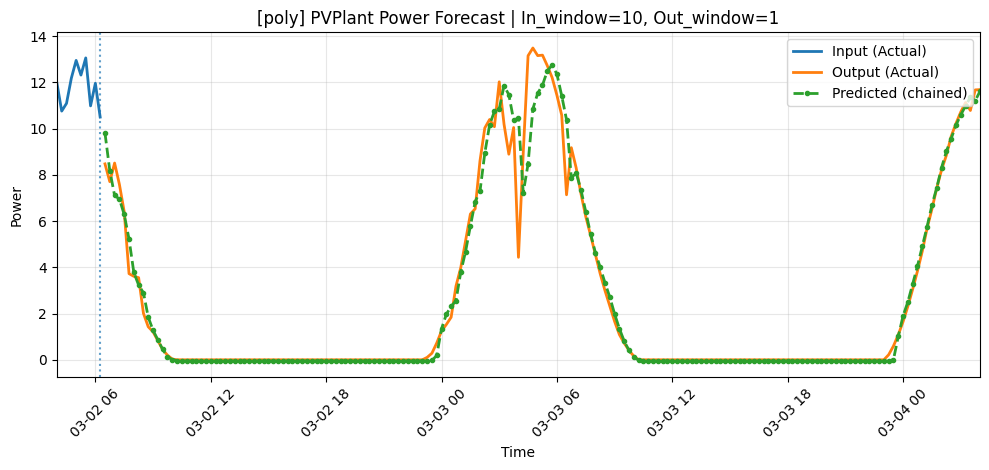

In [202]:
plot_Owaolabi_predictions_chained(
    None, Transformer, valid_loader, valid_origin, device,
    input_len=input_window, output_len=output_window, start_idx=0,
    std_scaler=y_standard_scaled, mm_scaler=y_minmax_scaled,logged=False, 
    view_days=2, tgt_station_name=tgt_station_name,
    save_path=f"plots/Owaolabi/Single_Transformer_{tgt_station_name}_2days_valid.png"
)

##### 3. CNN + Transformer 결합 모델

In [203]:
# CNN 파라미터 설정

in_channels = 8 # 입력 피처 수 (station의 기상 변수 + power)
out_channels = 64 # CNN에서 추출할 feature map 수 (입력 feature를 통해 out_channels 수 만큼 새로운 특징 추출)
kernel_size = 3 # 커널 크기
stride = 1 # kernel 이동 간격
dilation = 1 # kernel 사이의 간격
padding = 1 # 입력 양 쪽에 채워 넣는 padding 크기
groups = 1 # 1: default
bias = True # bias 사용
padding_mode = 'zeros' # padding 채우는 값
cnn_dropout = 0.1 # dropout 비율
pool_kernel_size = 2 # MaxPooling kernel size
pool_stride = 2 # MaxPooling stride
lstm_in_features = 32 # LSTM 입력 피처 수 # out_channels에서 fully connected layer로 축소
use_bn = True # Batch Normalization 사용 여부

In [204]:
# CNN 모델 생성
cnn = PVPlantCNN(
    in_channels=in_channels,
    out_channels=out_channels,
    kernel_size=kernel_size,
    stride=stride,
    dilation=dilation,
    padding=padding,
    groups=groups,
    bias=bias,
    padding_mode=padding_mode,
    dropout=cnn_dropout,
    pool_kernel_size=pool_kernel_size,
    pool_stride=pool_stride,
    lstm_in_features=lstm_in_features,
    use_bn=use_bn
).to(device)
cnn

PVPlantCNN(
  (cnn): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.1, inplace=False)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): LazyLinear(in_features=0, out_features=32, bias=True)
)

In [205]:
# 공통 파라미터
input_size  = lstm_in_features
d_model = 128
nhead = 8
dim_feedforward = 512
num_ts_layers = 3

In [206]:
Transformer = TimeSeriesTransformer(
    input_dim=input_size,
    d_model=d_model,
    nhead=nhead,
    num_layers=num_ts_layers,
    dim_feedforward=dim_feedforward,
    output_window=output_window,
    dropout=0.1,
    max_len = input_window,
).to(device)
Transformer

TimeSeriesTransformer(
  (embedding): TimeSeriesEmbedding(
    (input_proj): Linear(in_features=32, out_features=128, bias=True)
    (pos_encoder): PositionalEncoding()
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (enc_norm

In [207]:
criterion = nn.HuberLoss(delta=1.0, reduction="mean") # Huber Loss
# CNN+LSTM 파라미터를 하나의 optimizer에 넣기
# lr: station별로 수정 필요
optimizer = torch.optim.Adam(list(cnn.parameters()) + list(Transformer.parameters()), lr=1e-4)

num_epochs = 180
best_loss = float('inf')
best_cnn_path = f'results/Owaolabi/best_cnn_{tgt_station_name}_(CNN_Transformer).pth'
best_transformer_path = f'results/Owaolabi/best_transformer_{tgt_station_name}_(CNN_Transformer).pth'

for epoch in range(1, num_epochs + 1):
    # 1. 학습
    train_loss = train_cnn_lstm(train_loader, cnn, Transformer, criterion, optimizer, device)

    # 2. 검증: 평균 손실
    overall_loss = evaluate_cnn_lstm(valid_loader, cnn, Transformer, criterion, device)

    # 3. best model 저장 
    if overall_loss < best_loss:
        best_loss = overall_loss
        torch.save(cnn.state_dict(), best_cnn_path)
        torch.save(Transformer.state_dict(), best_transformer_path)
        print(f"[{tgt_station_name}] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

    # 4. 출력: train / valid 평균 손실
    print(f"[{tgt_station_name}] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")

[poly] (001) Saved best | valid loss: 0.207836
[poly] (001) train 0.306226 | valid 0.207836
[poly] (002) Saved best | valid loss: 0.139773
[poly] (002) train 0.135654 | valid 0.139773
[poly] (003) Saved best | valid loss: 0.072258
[poly] (003) train 0.087697 | valid 0.072258
[poly] (004) Saved best | valid loss: 0.053646
[poly] (004) train 0.062729 | valid 0.053646
[poly] (005) Saved best | valid loss: 0.046206
[poly] (005) train 0.052903 | valid 0.046206
[poly] (006) Saved best | valid loss: 0.043065
[poly] (006) train 0.046826 | valid 0.043065
[poly] (007) train 0.043471 | valid 0.045805
[poly] (008) Saved best | valid loss: 0.033851
[poly] (008) train 0.040547 | valid 0.033851
[poly] (009) train 0.037807 | valid 0.034291
[poly] (010) train 0.035717 | valid 0.034718
[poly] (011) Saved best | valid loss: 0.031283
[poly] (011) train 0.034494 | valid 0.031283
[poly] (012) Saved best | valid loss: 0.028327
[poly] (012) train 0.033122 | valid 0.028327
[poly] (013) train 0.033273 | valid 0

In [208]:
val_mae, val_rmse, val_mape, val_r2 = metrics_cnn_lstm(
    best_cnn_path, best_transformer_path, cnn, Transformer,
    valid_loader, y_standard_scaled, y_minmax_scaled, logged=False, device=device
)
print(f"[{tgt_station_name} CNN_Transformer] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")

[poly CNN_Transformer] Valid MAE: 0.3987, RMSE: 0.8738, MAPE: 92353.2500, R2: 0.9718


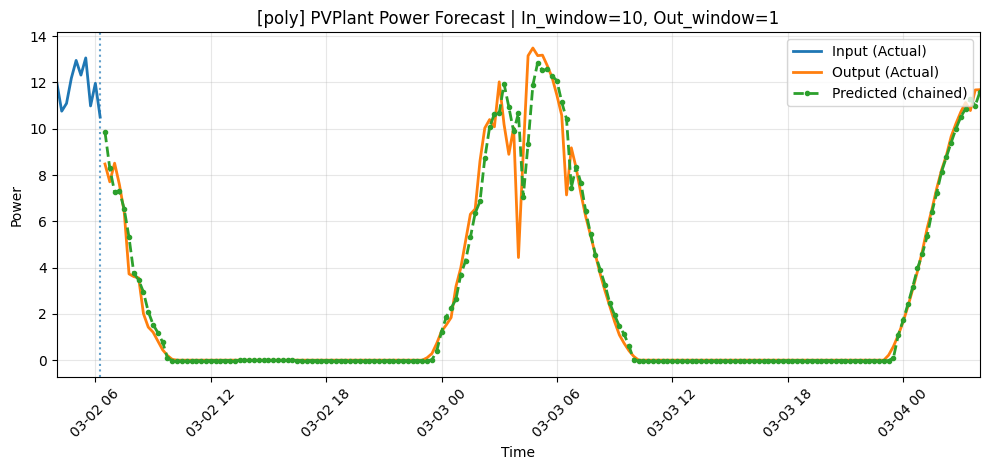

In [209]:
plot_Owaolabi_predictions_chained(
    cnn, Transformer, valid_loader, valid_origin, device,
    input_len=input_window, output_len=output_window, start_idx=0,
    std_scaler=y_standard_scaled, mm_scaler=y_minmax_scaled,logged=False, 
    view_days=2, tgt_station_name=tgt_station_name,
    save_path=f"plots/Owaolabi/CNN_Transformer_{tgt_station_name}_2days_valid.png"
)

## END